# Projet 1 : Modélisation Prédictive et Aide à la Décision Marketing Bancaire
### Auteur : Patrice Neussi
### Institution : École Nationale Supérieure Polytechnique de Yaoundé (ENSPY)

## 1. Introduction et Problématique
Dans le secteur bancaire, l'optimisation des campagnes de marketing direct est essentielle pour maximiser le taux de conversion tout en minimisant les coûts opérationnels liés au démarchage téléphonique. Ce projet vise à concevoir un modèle d'apprentissage supervisé capable de prédire si un client potentiel souscrira à un dépôt à terme (variable cible `y` $\in \{0, 1\}$).

Le problème est formulé comme une classification binaire sous contrainte de déséquilibre de classe sévère (~88% de non-souscriptions contre ~12% de souscriptions). Pour y répondre, nous proposons un classifieur d'ensemble hybride combinant :
1. La **Régression Logistique** comme modèle linéaire baseline.
2. La **Forêt Aléatoire** (Random Forest) pour capturer les non-linéarités et les interactions de caractéristiques.
3. Un **Perceptron Multicouche** (MLP) entraîné avec PyTorch pour l'extraction automatique de caractéristiques de haut niveau.

Les prédictions de ces trois classifieurs sont agrégées via un vote pondéré (Soft Voting).

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
print("Librairies importées avec succès.")

Librairies importées avec succès.


## 2. Analyse Exploratoire des Données (EDA)
Nous chargeons d'abord le jeu de données marketing bancaire (UCI Bank Marketing Dataset) pour analyser sa structure.

In [2]:
csv_path = "dataset/bank.csv"
if not os.path.exists(csv_path):
    csv_path = "dataset/bank-full.csv"
    
df = pd.read_csv(csv_path, sep=";")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
df.head()

Dimensions du dataset : 4521 lignes, 17 colonnes.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
class_counts = df['y'].value_counts()
class_pct = df['y'].value_counts(normalize=True) * 100
print("Distribution de la classe cible :")
for idx, val in class_counts.items():
    print(f"  Classe {idx} : {val} observations ({class_pct[idx]:.2f}%)")

Distribution de la classe cible :
  Classe no : 4000 observations (88.48%)
  Classe yes : 521 observations (11.52%)


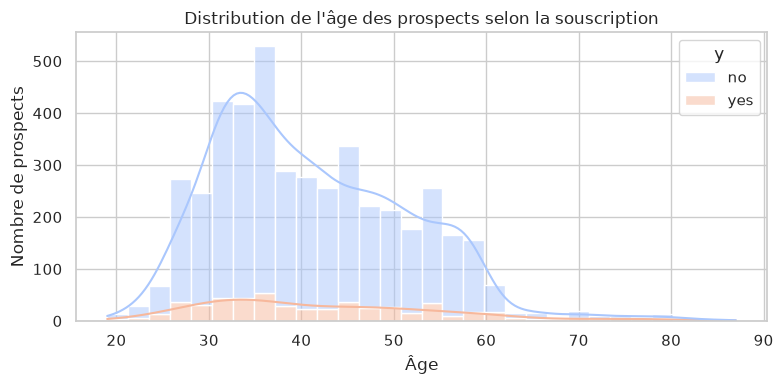

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='y', kde=True, bins=30, multiple='stack', palette='coolwarm')
plt.title("Distribution de l'âge des prospects selon la souscription")
plt.xlabel("Âge")
plt.ylabel("Nombre de prospects")
plt.tight_layout()
plt.show()

/tmp/ipykernel_217187/3691923676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='y', y='log_balance', palette='Set2')


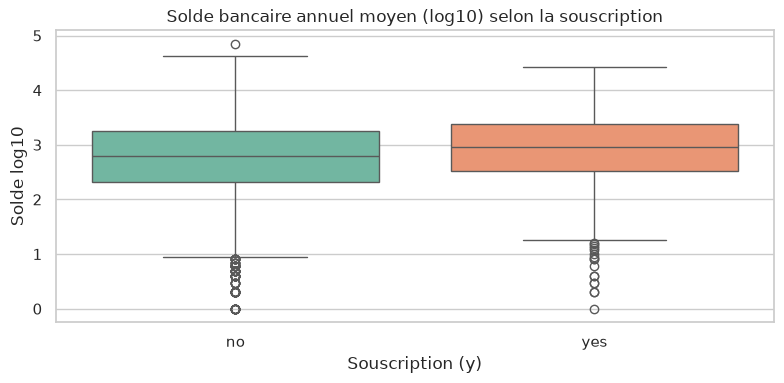

In [5]:
plt.figure(figsize=(8, 4))
df_filtered = df[df['balance'] > 0].copy()
df_filtered['log_balance'] = np.log10(df_filtered['balance'])
sns.boxplot(data=df_filtered, x='y', y='log_balance', palette='Set2')
plt.title("Solde bancaire annuel moyen (log10) selon la souscription")
plt.xlabel("Souscription (y)")
plt.ylabel("Solde log10")
plt.tight_layout()
plt.show()

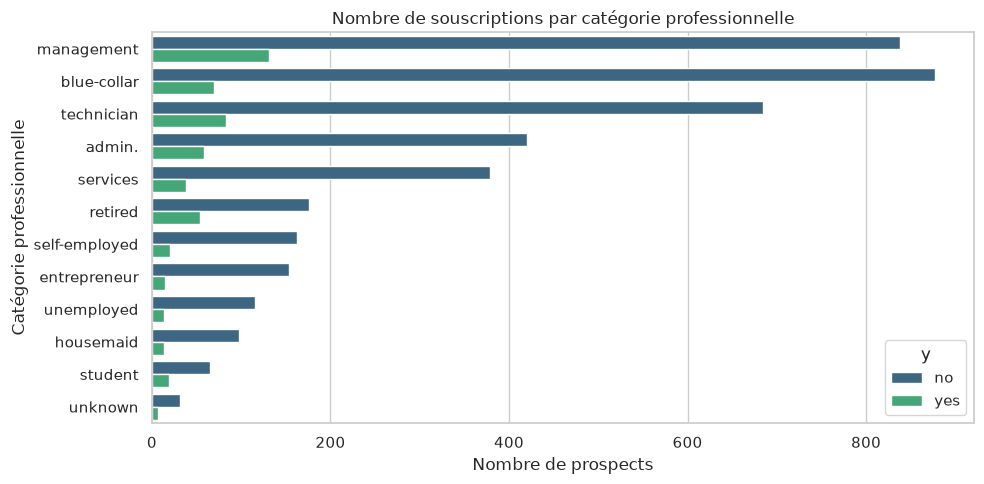

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='job', hue='y', order=df['job'].value_counts().index, palette='viridis')
plt.title("Nombre de souscriptions par catégorie professionnelle")
plt.xlabel("Nombre de prospects")
plt.ylabel("Catégorie professionnelle")
plt.tight_layout()
plt.show()

## 3. Prétraitement et Pipeline de Feature Engineering
Les variables qualitatives doivent être encodées en One-Hot, tandis que les attributs numériques doivent être cadrés à l'échelle pour stabiliser les gradients de la régression logistique et du réseau de neurones.

In [7]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

X = df.drop(columns=['y'])
y = df['y'].apply(lambda val: 1 if val == 'yes' else 0).values

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_transformed = preprocessor.fit_transform(X)
print(f"Dimensions des données prétraitées : {X_transformed.shape}")

Dimensions des données prétraitées : (4521, 51)


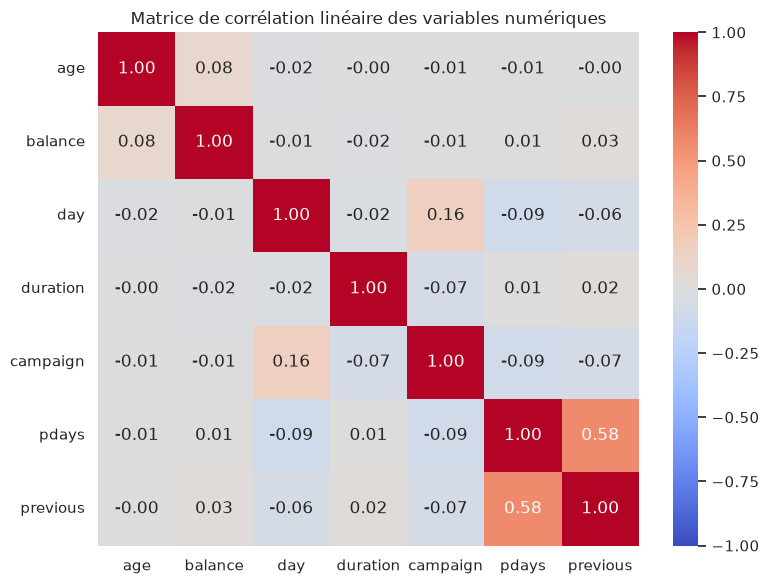

In [8]:
plt.figure(figsize=(8, 6))
corr_matrix = pd.DataFrame(X_transformed[:, :len(num_cols)], columns=num_cols).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de corrélation linéaire des variables numériques")
plt.tight_layout()
plt.show()

## 4. Fondements Mathématiques des Modèles Implémentés

### 4.1 Régression Logistique
Le modèle prédit la probabilité $\hat{y} = P(y=1|x)$ via la fonction logistique standard :
$$\hat{y} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$
La fonction de coût minimisée avec régularisation $L_2$ est la perte de cross-entropy binaire :
$$\mathcal{L}(w, b) = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln \hat{y}_i + (1 - y_i) \ln (1 - \hat{y}_i) \right] + \frac{\lambda}{2} \|w\|^2_2$$

### 4.2 Forêt Aléatoire (Random Forest)
Algorithme de Bagging de $B$ arbres de décision. Pour chaque noeud, le split optimal maximise le gain d'information basé sur l'impureté de Gini :
$$I_G(p) = 1 - \sum_{c \in \{0, 1\}} p_c^2$$

### 4.3 Perceptron Multicouche (PyTorch MLP)
Un réseau de neurones profonds à deux couches cachées. La propagation avant calcule :
$$h^{(1)} = \text{ReLU}(W^{(1)} x + b^{(1)})$$
$$h^{(2)} = \text{ReLU}(W^{(2)} h^{(1)} + b^{(2)})$$
$$\hat{y} = \text{Sigmoid}(W^{(3)} h^{(2)} + b^{(3)})$$
L'entraînement utilise l'algorithme Adam pour mettre à jour les poids par rétropropagation du gradient de la perte d'entropie croisée.

In [9]:
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim, hidden_dim=64, epochs=15, batch_size=64, lr=0.005):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.model = None
        self.classes_ = np.array([0, 1])
        
    def fit(self, X, y):
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim // 2, 1),
            nn.Sigmoid()
        )
        
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y).unsqueeze(1)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.BCELoss()
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self
        
    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X)
        with torch.no_grad():
            prob1 = self.model(X_tensor).numpy().flatten()
        prob0 = 1.0 - prob1
        return np.column_stack([prob0, prob1])
        
    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return (prob >= 0.5).astype(int)

## 5. Entraînement et Validation Croisée Stratifiée (K-Fold)
Nous évaluons les trois classifieurs de base par une validation croisée à 5 plis pour assurer la robustesse de l'évaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

models_dict = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'RandomForest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'PyTorchMLP': PyTorchMLPClassifier(input_dim=X_train.shape[1])
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, clf in models_dict.items():
    auc_scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_k_train, X_k_val = X_train[train_idx], X_train[val_idx]
        y_k_train, y_k_val = y_train[train_idx], y_train[val_idx]
        
        clf.fit(X_k_train, y_k_train)
        probs = clf.predict_proba(X_k_val)[:, 1]
        auc_scores.append(roc_auc_score(y_k_val, probs))
        
    print(f"Modèle {name} : Mean ROC-AUC = {np.mean(auc_scores):.4f} +/- {np.std(auc_scores):.4f}")

Modèle LogisticRegression : Mean ROC-AUC = 0.8897 +/- 0.0041


Modèle RandomForest : Mean ROC-AUC = 0.9003 +/- 0.0023


Modèle PyTorchMLP : Mean ROC-AUC = 0.8741 +/- 0.0135


## 6. Construction et Évaluation du Classifieur d'Ensemble Final
Nous entraînons l'Ensemble de Vote Pondéré final sur la totalité du jeu d'entraînement.

In [11]:
class CustomVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, weights=None):
        self.estimators = estimators
        self.weights = weights if weights else [1.0] * len(estimators)
        
    def fit(self, X, y):
        for name, clf in self.estimators.items():
            clf.fit(X, y)
        return self
        
    def predict_proba(self, X):
        probs = []
        total_weight = sum(self.weights)
        for (name, clf), weight in zip(self.estimators.items(), self.weights):
            probs.append(clf.predict_proba(X) * weight)
        return sum(probs) / total_weight
        
    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return (prob >= 0.5).astype(int)

ensemble = CustomVotingClassifier(models_dict, weights=[1.0, 1.5, 1.2])
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       801
           1       0.52      0.64      0.58       104

    accuracy                           0.89       905
   macro avg       0.74      0.78      0.76       905
weighted avg       0.90      0.89      0.90       905



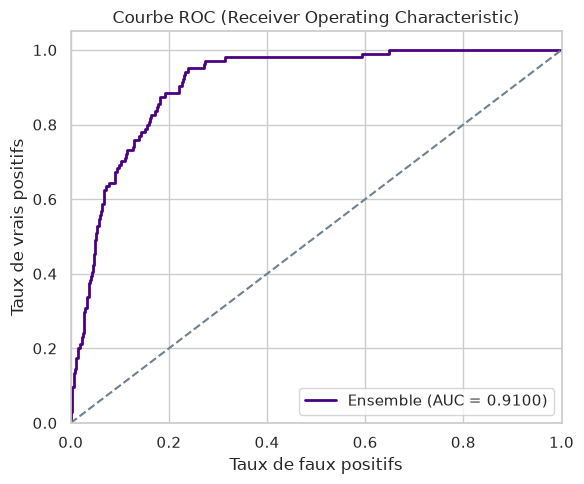

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='indigo', lw=2, label=f'Ensemble (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='slategray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Courbe ROC (Receiver Operating Characteristic)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

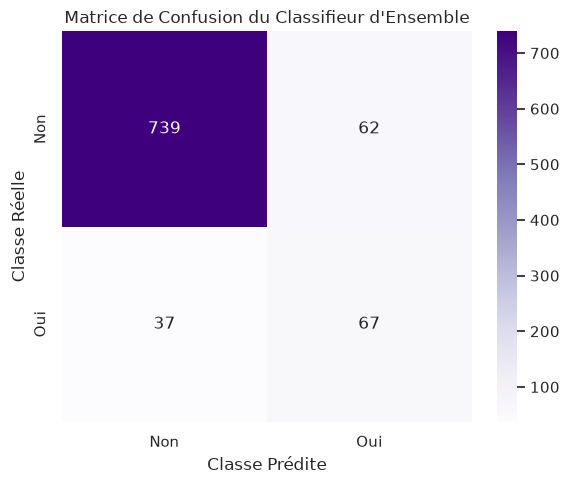

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
plt.title("Matrice de Confusion du Classifieur d'Ensemble")
plt.xlabel("Classe Prédite")
plt.ylabel("Classe Réelle")
plt.tight_layout()
plt.show()

## 7. Sérialisation du Modèle et Pipeline de Production

In [14]:
categorical_options = {}
for col in cat_cols:
    categorical_options[col] = list(df[col].unique())
    
assets = {
    'preprocessor': preprocessor,
    'logistic_regression': models_dict['LogisticRegression'],
    'random_forest': models_dict['RandomForest'],
    'pytorch_mlp': models_dict['PyTorchMLP'],
    'ensemble': ensemble,
    'features': {
        'num_cols': num_cols,
        'cat_cols': cat_cols,
        'categorical_options': categorical_options
    },
    'metrics': {
        'auc': float(auc),
        'accuracy': float(np.mean(y_pred == y_test))
    }
}

model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
with open(os.path.join(model_dir, "bank_model_assets.pkl"), "wb") as f:
    pickle.dump(assets, f)
print("Actifs du modèle sauvegardés avec succès dans models/bank_model_assets.pkl")

Actifs du modèle sauvegardés avec succès dans models/bank_model_assets.pkl
